# 🍽️ Food Image Classifier (CNN) + Nutrition Lookup

In [ ]:
!pip install tensorflow pandas numpy matplotlib -q
import tensorflow as tf, pandas as pd, numpy as np, matplotlib.pyplot as plt
print('TF:', tf.__version__)

TF: 2.20.0


## 1. Extract Dataset

In [ ]:
import zipfile
with zipfile.ZipFile('dataset (6).zip', 'r') as z:
    z.extractall('dataset')
print('Done.')

Done.


## 2. Load Nutrition CSV & Build Lookup

In [ ]:
df = pd.read_csv('final_matched_dataset (1).csv')
print('CSV shape:', df.shape)
print(df.head(3))

df['class_key'] = df['matched_name'].str.lower().str.strip().str.replace(' ', '_')

ALIASES = {
    'bakery':        'bread',
    'bread':         'rye_bread',
    'breakfast':     'breakfast_sausage_links',
    'burger':        'hamburger',
    'cake':          'yellow_cake',
    'cheese':        'cream_cheese',
    'chips':         'baked_chips',
    'chocolate':     'chocolate_bar',
    'coffee':        'coffee_creamer',
    'fish':          'white_fish',
    'fried_chicken': 'chicken',
    'grape':         'grapes',
    'ice_cream':     'ice_cream_cake',
    'juice':         'orange_juice',
    'lettuce':       'romaine_lettuce',
    'milk':          'oat_milk',
    'noodles':       'egg_noodles_cooked',
    'pizza':         'margherita_pizza',
    'popcorn':       'popcorn_air_popped',
    'potato':        'white_potato',
    'rice':          'spanish_rice',
    'salad':         'greek_salad',
    'shawarma':      'kebab',
    'smoothie':      'fruit_smoothie',
    'strawberry':    'strawberry',
    'sushi':         'tuna_sushi_maki',
    'watermelon':    'watermelon',
    'yogurt':        'greek_yogurt',
}

nutrition_by_key = (
    df.groupby('class_key')[['calories','protein','fat','carb']]
      .mean().round(2).to_dict(orient='index')
)

def get_nutrition(class_name):
    key = class_name.lower().replace(' ', '_')
    if key in nutrition_by_key:
        return nutrition_by_key[key]
    alias = ALIASES.get(key, '').lower().replace(' ', '_')
    if alias and alias in nutrition_by_key:
        return nutrition_by_key[alias]
    for k in nutrition_by_key:
        if key in k or k in key:
            return nutrition_by_key[k]
    return {'calories': None, 'protein': None, 'fat': None, 'carb': None}

for t in ['chicken', 'pizza', 'apple']:
    print(f'{t:15s} → {get_nutrition(t)}')

CSV shape: (13829, 9)
             name matched_name  \
0   chicken handi      chicken   
1   chicken mandi      chicken   
2  sticky chicken      chicken   

                                         ingredients category portion  \
0  Chicken, Onion, Tomatoes, Garlic, Ginger paste...     meat   100 g   
1  Chicken, Basmati Rice, Water, Onion, Garlic, G...     meat   100 g   
2  Chicken drumsticks, Soy Sauce, Honey, Olive Oi...     meat   100 g   

   calories  protein   fat  carb  
0     166.0     21.4  1.79   0.0  
1     166.0     21.4  1.79   0.0  
2     166.0     21.4  1.79   0.0  
chicken         → {'calories': 166.0, 'protein': 21.4, 'fat': 1.79, 'carb': 0.0}
pizza           → {'calories': 240.0, 'protein': 10.6, 'fat': 9.41, 'carb': 24.7}
apple           → {'calories': 64.0, 'protein': 0.0, 'fat': 0.0, 'carb': 11.7}


## 3. Load Image Dataset

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

IMG_SIZE   = (128, 128)
BATCH_SIZE = 32
DATA_DIR   = 'dataset/dataset'

train_ds = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='training',
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)
val_ds = image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset='validation',
    seed=42, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(f'{num_classes} classes found')

AUTOTUNE = tf.data.AUTOTUNE
# NOTE: prefetch only on train (no cache before augmentation)
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 18120 files belonging to 64 classes.
Using 14496 files for training.
Found 18120 files belonging to 64 classes.
Using 3624 files for validation.
64 classes found


## 4. Build CNN Model

**Architecture designed to reach 60%+ val accuracy on 64 classes:**

- **4 Conv blocks** — each with Conv2D → BatchNorm → ReLU → MaxPool
- **Increasing filters**: 32 → 64 → 128 → 256 (learns simple → complex features)
- **Data augmentation** inside model (random flip, rotation, zoom, contrast)
- **BatchNormalization** after every conv — stabilizes training, reduces overfitting
- **Dropout** 0.3 + 0.4 — regularization
- **Dense(512)** head before final softmax
- Single normalization via `Rescaling(1./255)` inside model

In [ ]:
from tensorflow.keras import layers, models, Input

def build_cnn(num_classes, img_size=(128, 128)):
    inputs = Input(shape=(*img_size, 3))

    # ── Augmentation (training only) ──
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomZoom(0.15)(x)
    x = layers.RandomContrast(0.1)(x)

    # ── Single normalization ──
    x = layers.Rescaling(1./255)(x)

    # ── Conv Block 1: 32 filters ──
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.2)(x)

    # ── Conv Block 2: 64 filters ──
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    # ── Conv Block 3: 128 filters ──
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # ── Conv Block 4: 256 filters ──
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(256, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)   # better than Flatten for generalization
    x = layers.Dropout(0.4)(x)

    # ── Classification head ──
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inputs, outputs)

model = build_cnn(num_classes)
model.summary(line_length=80)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_flip (RandomFlip)          │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_rotation (RandomRotation)  │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)          │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ random_contrast (RandomContrast)  │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ rescaling (Rescaling)             │ (None, 128, 128, 3)      │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d (Conv2D)                   │ (None, 128, 128, 32)     │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization               │ (None, 128, 128, 32)     │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation (Activation)           │ (None, 128, 128, 32)     │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 128, 128, 32)     │         9,248 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_1             │ (None, 128, 128, 32)     │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_1 (Activation)         │ (None, 128, 128, 32)     │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 64, 64, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)                 │ (None, 64, 64, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_2             │ (None, 64, 64, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_2 (Activation)         │ (None, 64, 64, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)                 │ (None, 64, 64, 64)       │        36,928 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_3             │ (None, 64, 64, 64)       │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_3 (Activation)         │ (None, 64, 64, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 32, 32, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)          

 Total params: 1,342,560 (5.12 MB)

 Trainable params: 1,339,616 (5.11 MB)

 Non-trainable params: 2,944 (11.50 KB)

## 5. Compile & Train

**Learning rate schedule:** starts at 1e-3, reduces on plateau. Early stopping restores best weights.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_cnn.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,          # early stopping will kick in well before 50
    callbacks=callbacks
)

Epoch 1/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.3412 - loss: 2.4185
Epoch 1: val_accuracy improved from None to 0.26021, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
453/453 ━━━━━━━━━━━━━━━━━━━━ 64s 127ms/step - accuracy: 0.3295 - loss: 2.4654 - val_accuracy: 0.2602 - val_loss: 2.9458 - learning_rate: 0.0010
Epoch 2/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3398 - loss: 2.4350
Epoch 2: val_accuracy improved from 0.26021 to 0.31319, saving model to best_cnn.keras

Epoch 2: finished saving model to best_cnn.keras
453/453 ━━━━━━━━━━━━━━━━━━━━ 56s 124ms/step - accuracy: 0.3360 - loss: 2.4547 - val_accuracy: 0.3132 - val_loss: 2.6066 - learning_rate: 0.0010
Epoch 3/50
453/453 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.3483 - loss: 2.4054
Epoch 3: val_accuracy did not improve from 0.31319
453/453 ━━━━━━━━━━━━━━━━━━━━ 56s 124ms/step - accuracy: 0.3371 - loss: 2.4268 - val_accuracy: 0.2950 - val_loss: 2.7402 - lear

## 6. Evaluation

In [ ]:
loss, acc = model.evaluate(val_ds)
print(f'\n✅ Validation Accuracy: {acc*100:.1f}%')
print(f'   Validation Loss:     {loss:.4f}')

114/114 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4205 - loss: 2.1840

✅ Validation Accuracy: 42.1%
   Validation Loss:     2.1840


## 7. Training Curves

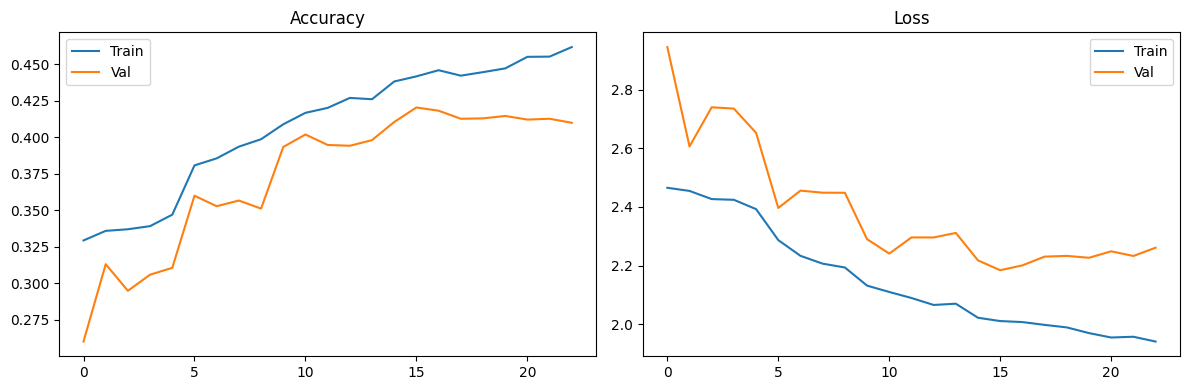

In [ ]:
ep       = range(len(history.history['accuracy']))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ep, history.history['accuracy'],     label='Train')
axes[0].plot(ep, history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(ep, history.history['loss'],         label='Train')
axes[1].plot(ep, history.history['val_loss'],     label='Val')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout(); plt.show()

## 8. Predict Image → Food Class + Nutrition

**هنا بيتربط الـ CNN بالـ CSV:**
- الـ CNN بتتوقع اسم الـ class من الصورة
- `get_nutrition()` بتجيب سعرات وبروتين ودهون وكارب من الـ CSV

In [ ]:
from PIL import Image as PILImage
import os, random

def predict_with_nutrition(image_path, top_k=3):
    img  = PILImage.open(image_path).convert('RGB').resize((128, 128))
    arr  = np.array(img)[np.newaxis, ...].astype('float32')
    preds    = model.predict(arr, verbose=0)[0]
    top_idx  = preds.argsort()[-top_k:][::-1]

    print(f'\n📸 {os.path.basename(image_path)}')
    print('─' * 45)
    for rank, idx in enumerate(top_idx, 1):
        cls  = class_names[idx]
        conf = preds[idx] * 100
        nutr = get_nutrition(cls)
        print(f'  #{rank} {cls.upper():20s} ({conf:.1f}%)')
        if nutr['calories'] is not None:
            print(f'      🔥 {nutr["calories"]:.0f} kcal | '
                  f'💪 {nutr["protein"]:.1f}g protein | '
                  f'🧈 {nutr["fat"]:.1f}g fat | '
                  f'🌾 {nutr["carb"]:.1f}g carb  (per 100g)')
        print()
    return class_names[top_idx[0]], preds[top_idx[0]]*100

# Test on 5 random validation images
random.seed(42)
for cls in random.sample(class_names, 5):
    cls_dir = os.path.join(DATA_DIR, cls)
    files   = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        img_path = os.path.join(cls_dir, random.choice(files))
        print(f'[True: {cls}]')
        pred_cls, conf = predict_with_nutrition(img_path)
        print(f'  → {"✅" if pred_cls==cls else "❌"} Predicted: {pred_cls}\n')

[True: chips]

📸 chips_56.jpg
─────────────────────────────────────────────
  #1 BURGER               (27.8%)
      🔥 297 kcal | 💪 17.5g protein | 🧈 14.4g fat | 🌾 20.7g carb  (per 100g)

  #2 BURRITO              (7.9%)
      🔥 239 kcal | 💪 9.4g protein | 🧈 4.1g fat | 🌾 32.9g carb  (per 100g)

  #3 POPCORN              (7.9%)
      🔥 442 kcal | 💪 0.8g protein | 🧈 0.0g fat | 🌾 12.8g carb  (per 100g)

  → ❌ Predicted: burger

[True: beef]

📸 beef_73.jpg
─────────────────────────────────────────────
  #1 BEEF                 (40.2%)
      🔥 156 kcal | 💪 20.0g protein | 🧈 5.9g fat | 🌾 0.0g carb  (per 100g)

  #2 KEBAB                (36.3%)
      🔥 158 kcal | 💪 14.3g protein | 🧈 14.3g fat | 🌾 57.1g carb  (per 100g)

  #3 TUNA                 (2.7%)
      🔥 126 kcal | 💪 5.7g protein | 🧈 3.8g fat | 🌾 10.4g carb  (per 100g)

  → ✅ Predicted: beef

[True: milk]

📸 milk_248.jpg
─────────────────────────────────────────────
  #1 FALAFEL              (26.0%)
      🔥 350 kcal | 💪 8.3g protein | 🧈 

## 9. Visual Grid

/tmp/ipykernel_10241/3725986187.py:27: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_10241/3725986187.py:27: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


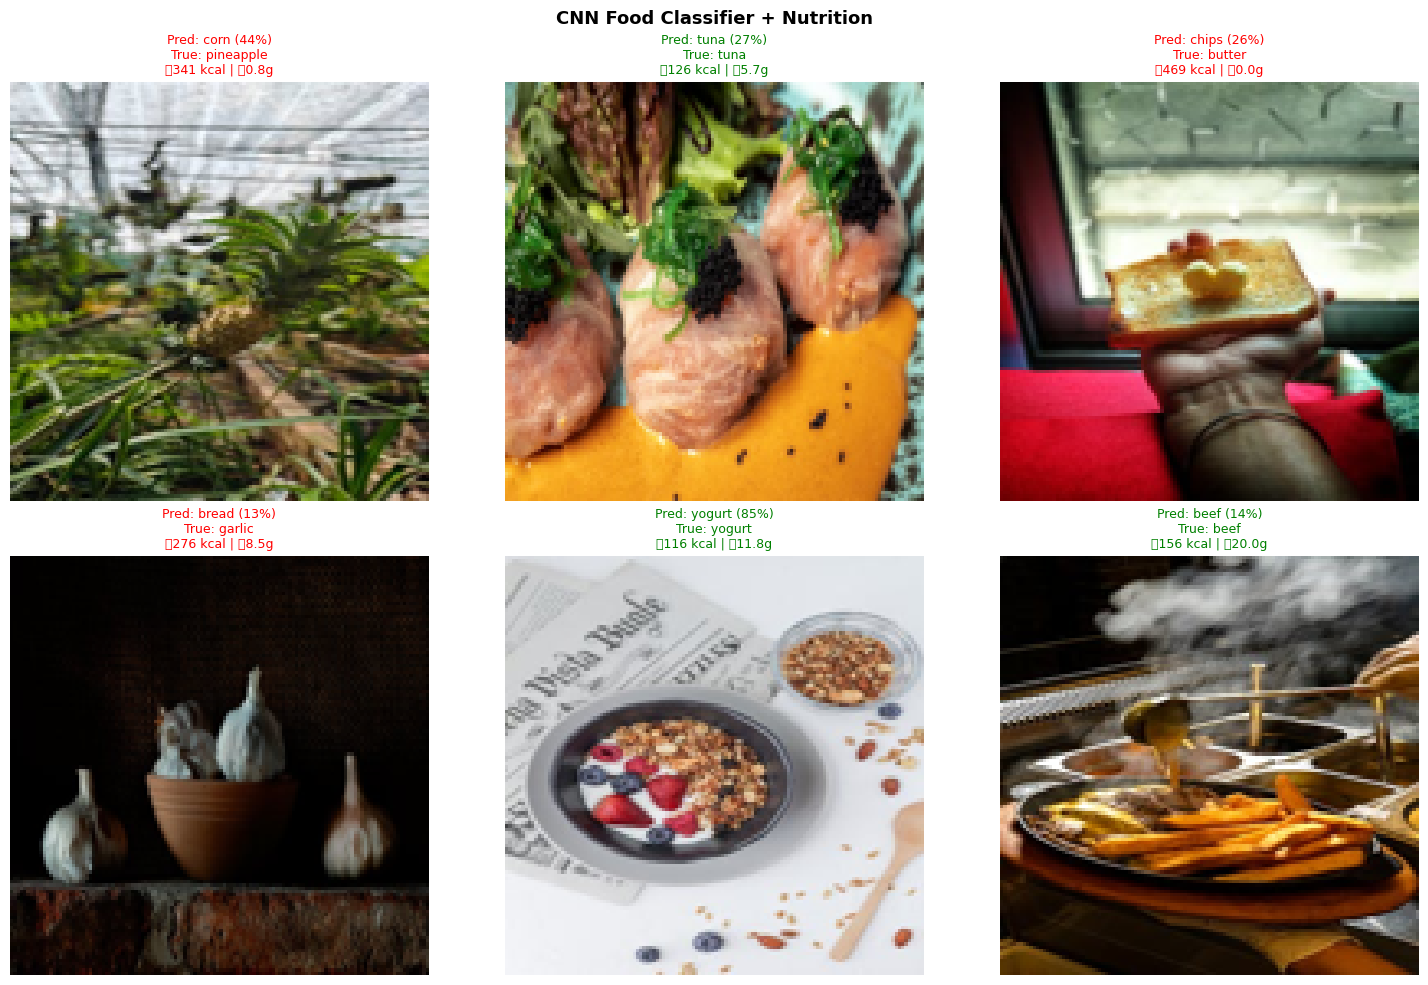

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
random.seed(7)
vis = []
for cls in random.sample(class_names, 6):
    cls_dir = os.path.join(DATA_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if files:
        vis.append((os.path.join(cls_dir, random.choice(files)), cls))

for ax, (img_path, true_cls) in zip(axes.flatten(), vis):
    img  = PILImage.open(img_path).convert('RGB').resize((128,128))
    arr  = np.array(img)[np.newaxis,...].astype('float32')
    pred = model.predict(arr, verbose=0)[0]
    pred_cls = class_names[pred.argmax()]
    conf     = pred.max() * 100
    nutr     = get_nutrition(pred_cls)

    ax.imshow(img)
    color = 'green' if pred_cls == true_cls else 'red'
    title = f'Pred: {pred_cls} ({conf:.0f}%)\nTrue: {true_cls}'
    if nutr['calories']:
        title += f'\n🔥{nutr["calories"]:.0f} kcal | 💪{nutr["protein"]:.1f}g'
    ax.set_title(title, color=color, fontsize=9)
    ax.axis('off')

plt.suptitle('CNN Food Classifier + Nutrition', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import io, re
from PIL import Image as PILImage
import numpy as np

# ─────────────────────────────────────────────
# 🔹 STATE
# ─────────────────────────────────────────────
_state = {
    "best_cls":  None,
    "best_conf": None,
    "top_preds": None,
    "nutr":      None,
}

# ─────────────────────────────────────────────
# 🔹 NUTRITION LOOKUP (uses notebook's nutrition_by_key + ALIASES)
# ─────────────────────────────────────────────
def _lookup_nutr(cls):
    key = cls.lower().replace(' ', '_')
    if key in nutrition_by_key:
        return nutrition_by_key[key]
    # Try ALIASES
    alias = ALIASES.get(key, '')
    alias_key = alias.lower().replace(' ', '_')
    if alias_key and alias_key in nutrition_by_key:
        return nutrition_by_key[alias_key]
    # Partial match fallback
    for k in nutrition_by_key:
        if key in k or k in key:
            return nutrition_by_key[k]
    return {}


# ─────────────────────────────────────────────
# 🔹 IMAGE ANALYSIS
# ─────────────────────────────────────────────
def analyse_image(img_bytes, top_k=3):
    img = PILImage.open(io.BytesIO(img_bytes)).convert('RGB').resize((224, 224))
    arr = np.array(img)[np.newaxis, ...].astype('float32')
    preds   = model.predict(arr, verbose=0)[0]
    top_idx = preds.argsort()[-top_k:][::-1]
    top_preds = [(class_names[i], float(preds[i]) * 100) for i in top_idx]
    best_cls  = top_preds[0][0]
    best_conf = top_preds[0][1]
    nutr      = _lookup_nutr(best_cls)   # ✅ direct lookup
    return best_cls, best_conf, top_preds, nutr


# ─────────────────────────────────────────────
# 🔹 BOT LOGIC
# ─────────────────────────────────────────────
def build_bot_reply(user_text, best_cls, best_conf, top_preds, nutr, first=False):
    txt = user_text.lower().strip()

    # ── First message after image upload ──
    if first:
        tops = "\n".join(
            f"  {i+1}. {c.replace('_',' ').title()}  {p:.1f}%"
            for i, (c, p) in enumerate(top_preds)
        )
        nutr_text = ""
        if nutr and nutr.get('calories') is not None:
            nutr_text = (
                f"\n\n🍽 Nutrition per 100g:\n"
                f"  🔥 Calories : {nutr['calories']:.0f} kcal\n"
                f"  💪 Protein  : {nutr['protein']:.1f} g\n"
                f"  🧈 Fat      : {nutr['fat']:.1f} g\n"
                f"  🍞 Carbs    : {nutr['carb']:.1f} g"
            )
        return (
            f"📸 Image analysed!\n\n"
            f"🏆 Top predictions:\n{tops}\n\n"
            f"✅ Best guess: <b>{best_cls.replace('_',' ').title()}</b> ({best_conf:.1f}%)"
            f"{nutr_text}\n\n"
            f"💬 Ask me anything about this food!"
        )

    # ── No image uploaded yet — general food chat ──
    if best_cls is None:
        if any(w in txt for w in ['cal', 'calori', 'كالوري', 'سعر', 'حرار', 'kcal']):
            return "🔥 Calories depend on the food! Upload an image and I'll tell you exactly."
        if any(w in txt for w in ['protein', 'بروتين']):
            return "💪 Protein varies by food. Upload an image for specific info!"
        if any(w in txt for w in ['fat', 'دهن', 'دهون']):
            return "🧈 Fat content depends on the food. Try uploading an image!"
        if any(w in txt for w in ['carb', 'كارب', 'نشا', 'sugar', 'سكر']):
            return "🍞 Carbs vary a lot! Upload a food image and I'll check for you."
        if any(w in txt for w in ['healthy', 'health', 'رجيم', 'صح', 'مفيد']):
            return "⚖️ Generally: veggies & lean protein = healthy. Fried & sugary = less so! Upload an image for a specific answer."
        if any(w in txt for w in ['hi', 'hello', 'hey', 'مرحبا', 'أهلا', 'هاي']):
            return "👋 Hi! I'm your food assistant 🍽️ Upload a food image and I'll analyse it for you!"
        if any(w in txt for w in ['thanks', 'thank', 'شكرا', 'تسلم', 'يسلمو']):
            return "😊 You're welcome! Upload a food image anytime."
        if any(w in txt for w in ['pizza','burger','sushi','salad','chicken','rice',
                                   'بيتزا','برجر','سوشي','سلطة','دجاج','أرز']):
            return "😋 Sounds delicious! Upload a photo of it and I'll give you the full nutrition info."
        return "🤖 I'm your food assistant! Upload a food image 📷 and ask me about calories, protein, fat, carbs, or if it's healthy."

    # ── Calories ──
    if any(w in txt for w in ['cal', 'calori', 'كالوري', 'سعر', 'حرار', 'kcal']):
        if nutr and nutr.get('calories') is not None:
            return f"🔥 <b>{best_cls.replace('_',' ').title()}</b> has <b>{nutr['calories']:.0f} kcal</b> per 100g."
        return "No calorie data available for this food."

    # ── Protein ──
    if any(w in txt for w in ['protein', 'بروتين']):
        if nutr and nutr.get('protein') is not None:
            return f"💪 Protein: <b>{nutr['protein']:.1f}g</b> per 100g."
        return "No protein data available."

    # ── Fat ──
    if any(w in txt for w in ['fat', 'دهن', 'دهون']):
        if nutr and nutr.get('fat') is not None:
            return f"🧈 Fat: <b>{nutr['fat']:.1f}g</b> per 100g."
        return "No fat data available."

    # ── Carbs ──
    if any(w in txt for w in ['carb', 'كارب', 'نشا', 'sugar', 'سكر']):
        if nutr and nutr.get('carb') is not None:
            return f"🍞 Carbs: <b>{nutr['carb']:.1f}g</b> per 100g."
        return "No carbs data available."

    # ── Full nutrition ──
    if any(w in txt for w in ['nutrition', 'all', 'كل', 'كامل', 'summary', 'تغذي', 'قيمة']):
        if nutr and nutr.get('calories') is not None:
            return (
                f"📊 <b>{best_cls.replace('_',' ').title()}</b> per 100g:<br>"
                f"🔥 {nutr['calories']:.0f} kcal &nbsp;|&nbsp; "
                f"💪 {nutr['protein']:.1f}g protein &nbsp;|&nbsp; "
                f"🧈 {nutr['fat']:.1f}g fat &nbsp;|&nbsp; "
                f"🍞 {nutr['carb']:.1f}g carbs"
            )
        return "No nutrition data available."

    # ── Confidence ──
    if any(w in txt for w in ['confidence', 'confident', 'sure', 'نسبة', 'متأكد', 'مؤكد', 'percent']):
        return f"🎯 I'm <b>{best_conf:.1f}%</b> confident this is <b>{best_cls.replace('_',' ').title()}</b>."

    # ── Other predictions ──
    if any(w in txt for w in ['other', 'else', 'alternative', 'second', 'تاني', 'بديل', 'احتمال']):
        others = "<br>".join(
            f"  {i+2}. {c.replace('_',' ').title()} — {p:.1f}%"
            for i, (c, p) in enumerate(top_preds[1:])
        )
        return f"🔍 Other possibilities:<br>{others}"

    # ── Healthy ──
    if any(w in txt for w in ['healthy', 'health', 'good', 'bad', 'diet', 'رجيم', 'صح', 'مفيد']):
        if nutr and nutr.get('calories') is not None:
            cal = nutr['calories']
            tag = ("🟢 low-calorie — great choice!" if cal < 150
                   else "🟡 moderate — okay in portions." if cal < 300
                   else "🔴 high-calorie — enjoy in moderation.")
            return (
                f"⚖️ <b>{best_cls.replace('_',' ').title()}</b> is {tag}<br>"
                f"{cal:.0f} kcal | {nutr['protein']:.1f}g protein | "
                f"{nutr['fat']:.1f}g fat | {nutr['carb']:.1f}g carbs"
            )
        return "Not enough data to assess healthiness."

    # ── What is this ──
    if any(w in txt for w in ['what', 'ايه', 'إيه', 'identify', 'food', 'اكل', 'ده']):
        return f"🍽️ This looks like <b>{best_cls.replace('_',' ').title()}</b> ({best_conf:.1f}% confidence)."

    # ── Greetings ──
    if any(w in txt for w in ['hi', 'hello', 'hey', 'مرحبا', 'أهلا', 'هاي']):
        return f"👋 Hi! I detected <b>{best_cls.replace('_',' ').title()}</b>. What would you like to know?"

    # ── Thanks ──
    if any(w in txt for w in ['thanks', 'thank', 'شكرا', 'تسلم', 'يسلمو']):
        return "😊 You're welcome! Upload another image anytime."

    # ── Fallback ──
    return (
        f"🤔 I can answer about:<br>"
        f"• Calories / Protein / Fat / Carbs<br>"
        f"• Full nutrition summary<br>"
        f"• How confident I am<br>"
        f"• Other predictions<br>"
        f"• Is it healthy?<br><br>"
        f"(Detected: <b>{best_cls.replace('_',' ').title()}</b>)"
    )


# ─────────────────────────────────────────────
# 🔹 CHAT RENDER
# ─────────────────────────────────────────────
def show_msg(msg, who="bot"):
    bg    = "#e8f5e9" if who == "bot" else "#e3f2fd"
    align = "left"    if who == "bot" else "right"
    icon  = "🤖"       if who == "bot" else "🧑"
    msg_html = msg.replace('\n', '<br>')
    with chat_out:
        display(HTML(f"""
        <div style="text-align:{align}; margin:5px 2px;">
          <span style="font-size:1.05em">{icon}</span>
          <span style="
            display:inline-block; max-width:80%; padding:9px 13px;
            background:{bg}; border-radius:12px;
            font-size:0.91em; color:#111; text-align:left;
            font-family:'Segoe UI',sans-serif;
            box-shadow:0 1px 3px rgba(0,0,0,.07);
          ">{msg_html}</span>
        </div>
        """))


# ─────────────────────────────────────────────
# 🔹 WIDGETS
# ─────────────────────────────────────────────
upload_btn = widgets.FileUpload(
    accept='image/*', multiple=False,
    description='📷 Upload Image',
    layout=widgets.Layout(width='180px')
)

text_input = widgets.Text(
    placeholder='Ask something about food...',
    layout=widgets.Layout(width='72%', height='36px')
)

send_btn = widgets.Button(
    description='Send ➤', button_style='primary',
    layout=widgets.Layout(width='90px', height='36px')
)

clear_btn = widgets.Button(
    description='🗑 Clear', button_style='warning',
    layout=widgets.Layout(width='80px', height='36px')
)

chat_out = widgets.Output(layout=widgets.Layout(
    border='1px solid #ddd',
    min_height='300px', max_height='420px',
    overflow_y='auto', padding='10px',
))

img_out = widgets.Output(layout=widgets.Layout(
    width='200px', min_height='50px'
))

status_lbl = widgets.HTML(
    value='<span style="color:gray;font-size:.85em">No image uploaded yet.</span>'
)


# ─────────────────────────────────────────────
# 🔹 EVENTS
# ─────────────────────────────────────────────
def on_upload(change):
    if not upload_btn.value:
        return
    fname     = list(upload_btn.value.keys())[0]
    img_bytes = bytes(upload_btn.value[fname]['content'])

    with img_out:
        clear_output(wait=True)
        display(PILImage.open(io.BytesIO(img_bytes)).resize((190, 190)))

    status_lbl.value = f'<span style="color:green;font-size:.85em">✅ Loaded: {fname}</span>'

    best_cls, best_conf, top_preds, nutr = analyse_image(img_bytes)
    _state.update(best_cls=best_cls, best_conf=best_conf,
                  top_preds=top_preds, nutr=nutr)

    show_msg(build_bot_reply('', best_cls, best_conf, top_preds, nutr, first=True), 'bot')


def on_send(_=None):
    user_text = text_input.value.strip()
    if not user_text:
        return
    text_input.value = ''
    show_msg(user_text, 'user')
    reply = build_bot_reply(
        user_text,
        _state['best_cls'], _state['best_conf'],
        _state['top_preds'], _state['nutr']
    )
    show_msg(reply, 'bot')


def on_clear(_):
    with chat_out:
        clear_output()
    with img_out:
        clear_output()
    _state.update(best_cls=None, best_conf=None, top_preds=None, nutr=None)
    status_lbl.value = '<span style="color:gray;font-size:.85em">No image uploaded yet.</span>'
    show_msg("👋 Hi! I'm your food assistant 🍽️<br>Upload a food image 📷 or ask me a general food question!", "bot")


upload_btn.observe(on_upload, names='value')
send_btn.on_click(on_send)
clear_btn.on_click(on_clear)
text_input.on_submit(on_send)   # ✅ Enter key sends

# ── Greeting on load ──
show_msg("👋 Hi! I'm your food assistant 🍽️<br>Upload a food image 📷 or ask me a general food question!", "bot")


# ─────────────────────────────────────────────
# 🔹 LAYOUT
# ─────────────────────────────────────────────
title = widgets.HTML("""
<div style="
  background:linear-gradient(135deg,#1b5e20,#43a047);
  color:white; padding:13px 18px; border-radius:10px; margin-bottom:8px;
  font-family:'Segoe UI',sans-serif;
">
  <h2 style="margin:0;font-size:1.3em;">🍽️ Food Chatbot</h2>
  <p style="margin:3px 0 0;font-size:.8em;opacity:.9;">
    Ask general food questions or upload an image for nutrition analysis!
  </p>
</div>
""")

left  = widgets.VBox([chat_out,
                      widgets.HBox([text_input, send_btn, clear_btn])],
                     layout=widgets.Layout(width='65%'))

right = widgets.VBox([
    widgets.HTML('<b style="font-family:Segoe UI;font-size:.88em">📷 Image preview</b>'),
    img_out,
    upload_btn,
    status_lbl
], layout=widgets.Layout(width='33%', padding='0 0 0 12px'))

display(title, widgets.HBox([left, right]))

HTML(value='\n<div style="\n  background:linear-gradient(135deg,#1b5e20,#43a047);\n  color:white; padding:13px…